## Data Loading and Initial Exploration

Before diving into our analysis, we first load the cleaned movie dataset and perform a brief inspection. This step ensures that our data is correctly formatted and provides an overview of the available columns, data types, and a sample of the records. This foundational check is essential for understanding the structure and content of the dataset, which will inform all subsequent analyses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataframe and
core_movies_df = pd.read_parquet("data-cleaning/parquet-data/core_movies_df_processed.parquet")
print(f"core_movies_df.info()\n{core_movies_df.info()}")
print(f"core_movies_df.head()\n{core_movies_df.head()}")

<class 'pandas.core.frame.DataFrame'>
Index: 830290 entries, 0 to 940970
Data columns (total 12 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   id                               830290 non-null  int64         
 1   title                            830288 non-null  object        
 2   global_release_year              830290 non-null  Int64         
 3   earliest_release_date            806912 non-null  datetime64[ns]
 4   earliest_release_month           806912 non-null  Int64         
 5   genres_list                      631831 non-null  object        
 6   production_countries_list        576614 non-null  object        
 7   is_primary_language_english      830290 non-null  bool          
 8   num_oscar_nominations            830290 non-null  int64         
 9   num_oscar_wins                   830290 non-null  int64         
 10  foreign_international_nominated  830290 non-null 


---

## Exploring Monthly Movie Release Patterns and the "Oscar Effect"

To investigate how the timing of movie releases may relate to Oscar strategies, we first prepare our dataset by ensuring valid release month and year information. We then map numeric months to their names for clearer visualization.

A custom plotting function is defined to visualize both the count and percentage of movies released in each month. Using this, we explore:

- The overall distribution of movie releases by month.
- How release patterns differ before and after the introduction of the Oscars in 1927.
- Whether films that are nominated for or win Oscars show distinct release timing compared to non-nominated films.

This analysis helps reveal whether studios strategically time releases to maximize awards potential, and how these patterns have evolved over time.

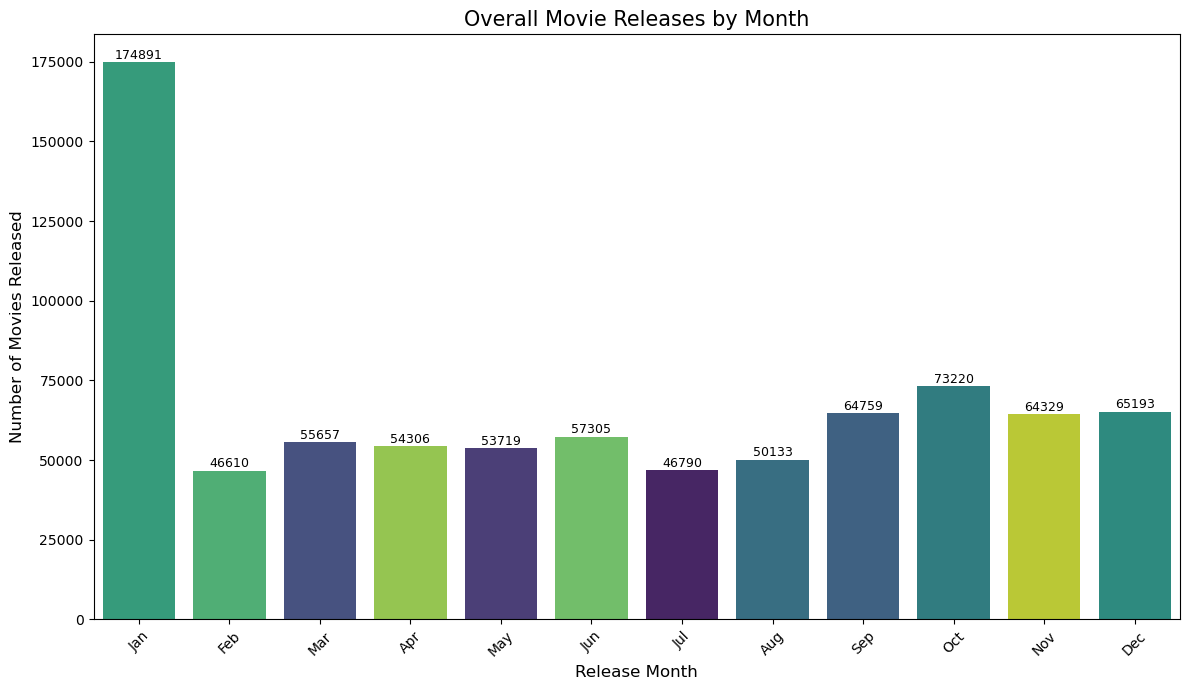

In [2]:
# Define the Oscar introduction year
oscar_intro_year = 1927

# Data preparation
analysis_df = core_movies_df.dropna(subset=['earliest_release_month', 'global_release_year']).copy()
analysis_df['earliest_release_month'] = analysis_df['earliest_release_month'].astype(int)
analysis_df['global_release_year'] = analysis_df['global_release_year'].astype(int)
analysis_df = analysis_df[analysis_df['earliest_release_month'].between(1, 12)]

# Use .map for direct month name conversion
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
analysis_df['release_month_name'] = analysis_df['earliest_release_month'].map(lambda x: month_names[x - 1])

def plot_monthly_distribution(data, title, ax, category_order=month_names, value_col=None, is_percentage=False):
    """
    Plots a bar chart of movie counts or percentages by release month.
    Reuses the function for both count and percentage plots.
    """
    if is_percentage:
        # Use hue for categories in percentage plot
        sns.barplot(x='release_month_name', y=value_col, hue='nominated_won', data=data, ax=ax, order=category_order,
                    palette="muted", legend=True)
        ax.set_ylabel("Percentage of Films within Category (%)", fontsize=12)
    else:
        # For count plot, use hue for release_month_name for consistent color and remove legend as it's redundant
        sns.countplot(x='release_month_name', data=data, ax=ax, order=category_order, palette="viridis",
                      hue='release_month_name', dodge=False, legend=False)
        ax.set_ylabel("Number of Movies Released", fontsize=12)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Release Month", fontsize=12)
    ax.tick_params(axis='x', labelrotation=45)

    # Annotate bars
    if not is_percentage:
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
    else:
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                            textcoords='offset points')
    plt.tight_layout()

# Plot overall monthly distribution
fig, ax = plt.subplots(figsize=(12, 7))
plot_monthly_distribution(
    analysis_df,
    "Overall Movie Releases by Month",
    ax
)
plt.show()

#### Interpreting the Monthly Release Patterns
The visualization above provides a clear overview of how movie releases are distributed throughout the calendar year.

What emerges are **Seasonal Peaks and Lulls** , reflecting industry cycles, audience habits, and possibly external factors such as holidays or major events.

### Analyzing montly release trends **Before** and **After** Oscar introduction

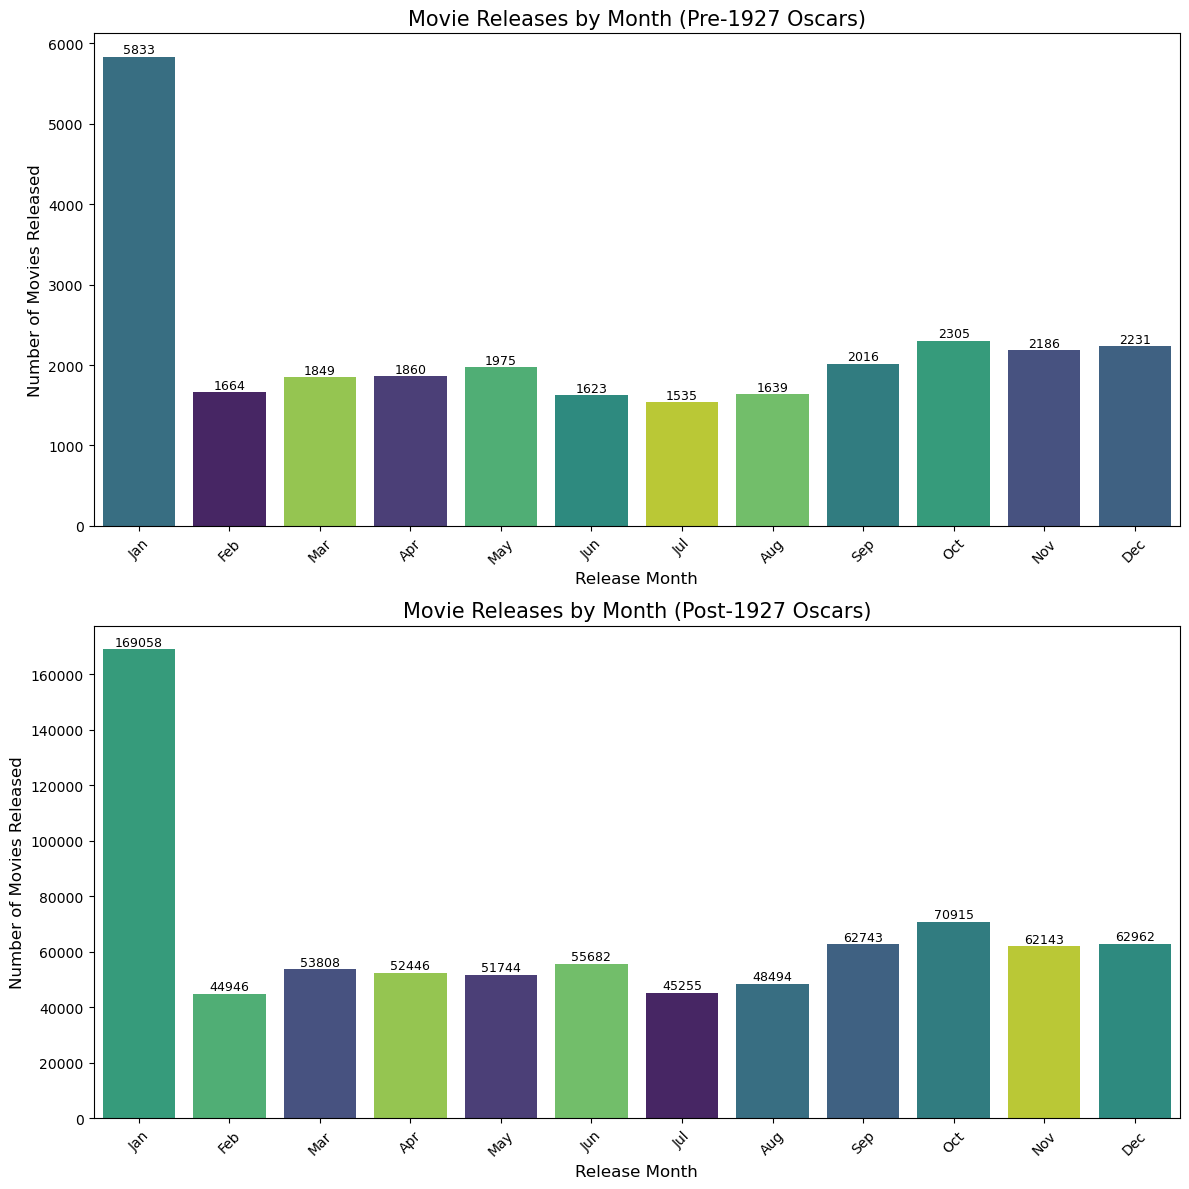

In [3]:

# Pre- vs. Post-Oscars
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
plot_monthly_distribution(
    analysis_df[analysis_df['global_release_year'] < oscar_intro_year],
    f"Movie Releases by Month (Pre-{oscar_intro_year} Oscars)",
    axes[0]
)
plot_monthly_distribution(
    analysis_df[analysis_df['global_release_year'] >= oscar_intro_year],
    f"Movie Releases by Month (Post-{oscar_intro_year} Oscars)",
    axes[1]
)
plt.tight_layout()
plt.show()


#### The Impact of the Oscars on Release Timing

The difference in monthly release patterns before and after the introduction of the Oscars is actually **quite small**. This negligible change is likely because the Oscars were established in 1927, which coincides with the very early years of the movie industry itself. As a result, both "pre-" and "post-" Oscar periods largely reflect the same foundational industry practices, and any strategic shifts in release timing would only become more pronounced as the industry and the awards matured over subsequent decades.

### Let's focus on Oscar Candidates and Non-Oscar Candidates

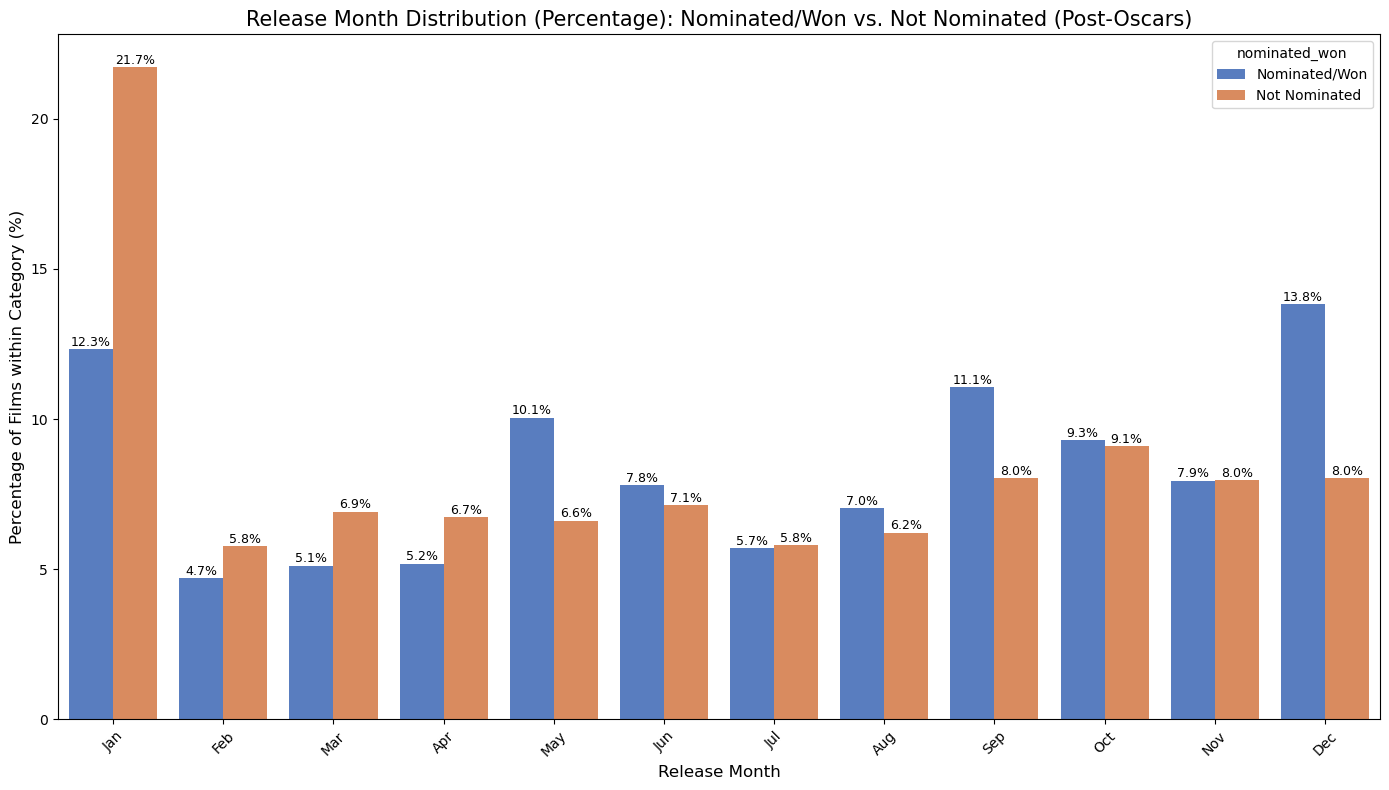

In [4]:
# Only considering movies released after the Oscars were introduced
post_oscars_df = analysis_df[analysis_df['global_release_year'] >= oscar_intro_year].copy()

# Create a nominated or won column
post_oscars_df['nominated_won'] = np.where(
    (post_oscars_df['num_oscar_nominations'] > 0) | (post_oscars_df['num_oscar_wins'] > 0),
    'Nominated/Won',
    'Not Nominated'
)

# Calculate counts per group
counts = post_oscars_df.groupby(['nominated_won', 'release_month_name']).size().reset_index(name='count')

# Calculate total per nominated_won
totals = counts.groupby('nominated_won')['count'].transform('sum')
counts['percentage'] = 100 * counts['count'] / totals

# Ensuring all months are present for both categories
all_months = pd.DataFrame({'release_month_name': month_names})
categories = counts['nominated_won'].unique()
full_percentage_df = pd.concat([
    all_months.assign(nominated_won=cat).merge(
        counts[counts['nominated_won'] == cat][['release_month_name', 'percentage', 'nominated_won']],
        on=['nominated_won', 'release_month_name'],
        how='left'
    ).fillna({'percentage': 0})
    for cat in categories
])

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
plot_monthly_distribution(
    full_percentage_df,
    "Release Month Distribution (Percentage): Nominated/Won vs. Not Nominated (Post-Oscars)",
    ax,
    is_percentage=True,
    value_col='percentage'
)
plt.show()

#### Strategic Timing: The Evolution of Oscar Season

The temporal analysis reveals fundamental shifts in Hollywood's release strategies following the Academy's establishment. While the overall industry maintains consistent seasonal patterns—with January peaks and summer lulls reflecting traditional business cycles, the introduction of the Oscars created a distinct bifurcation in release timing strategies.

**Divergent Release Philosophies:** The data exposes two distinct release ecosystems: Oscar-aspirational films gravitating toward year-end positioning, while mainstream entertainment maintains broader seasonal distribution patterns. This divergence suggests the industry has developed parallel track systems—one optimized for critical recognition, another for commercial performance.

**Industry Adaptation to Awards Culture:** The emergence of this "Oscar season" phenomenon illustrates how external institutional forces can reshape fundamental business practices. Studios have essentially created a specialized release window that prioritizes awards consideration over traditional commercial timing, demonstrating the significant cultural and economic influence of Academy recognition on industry behavior.

This temporal restructuring reveals the Academy's profound impact on not just what films get recognized, but when films get released—fundamentally altering the rhythm of the entertainment industry itself.

---

## Genre Trends and Oscar Recognition

Our investigation now turns to the Academy's genre preferences, examining which storytelling approaches consistently earn Oscar recognition and how these patterns have shifted throughout cinema history. We analyze the most celebrated genres among nominated films and track their evolutionary trajectory over time, revealing both the Academy's enduring biases and its gradual adaptations to changing cinematic landscapes.

### Mapping the Cinematic Universe: Genre Distribution Across All Films

To understand the Academy's selective preferences, we must first establish the foundational context of film production itself. This comprehensive genre analysis reveals the natural ecosystem of cinema, the vast universe of storytelling approaches that compete for both audience attention and critical recognition. By examining which genres dominate overall film production, we create an essential baseline that will illuminate the stark contrasts between what gets made and what gets celebrated when we later explore Oscar recognition patterns.

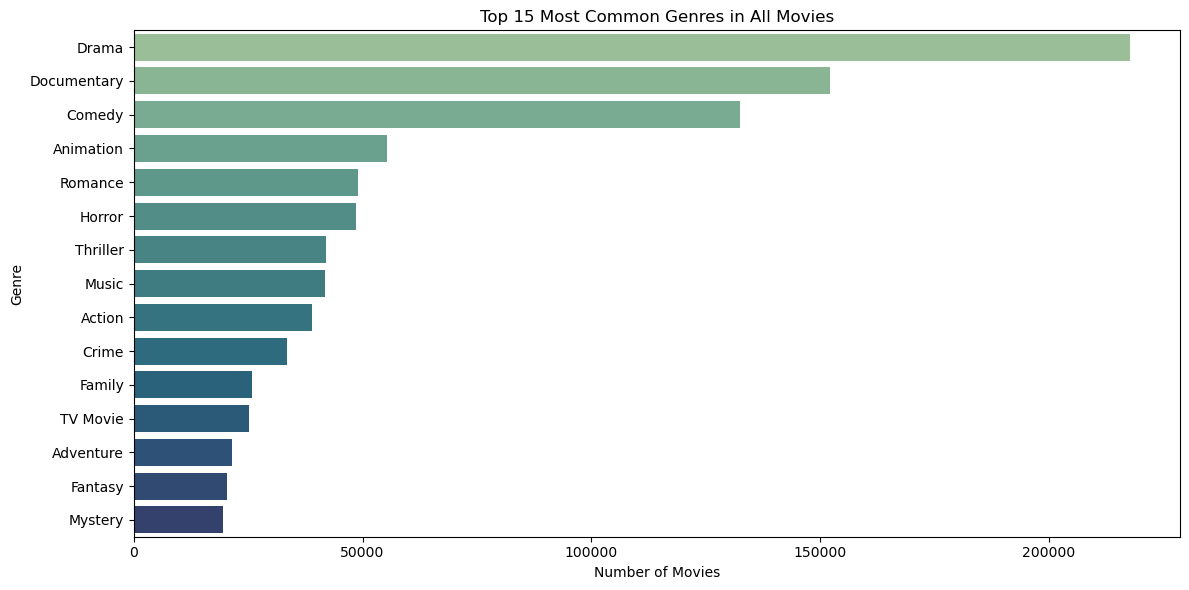

In [5]:
# Explode genres_list for all movies with valid genres
all_movies_with_genres = core_movies_df[
    core_movies_df['genres_list'].apply(lambda x: isinstance(x, list) and len(x) > 0)
].copy()
exploded_all_genres = all_movies_with_genres.explode('genres_list')

N_TOP_GENRES = 15

# Count genre occurrences
genre_counts_all = exploded_all_genres['genres_list'].value_counts().head(N_TOP_GENRES)

# Bar chart visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_counts_all.values,
    y=genre_counts_all.index,
    hue=genre_counts_all.index,
    palette="crest",
    legend=False
)
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Top 15 Most Common Genres in All Movies")
plt.tight_layout()
plt.show()

#### The Cinematic Landscape: Genre Production Patterns

The visualization reveals the foundational genre distribution across the entire film industry. Drama emerges as the clear leader in production volume, followed closely by Comedy and Documentary, demonstrating these genres' enduring commercial viability and creative flexibility.

This baseline distribution represents the natural ecosystem of film production, where market forces, audience preferences, and creative traditions shape what gets made.

Understanding this production landscape becomes essential when we examine Oscar recognition patterns, and allows us to distinguish between genres that succeed due to sheer volume versus those that achieve disproportionate critical acclaim. This foundation sets the stage for identifying the Academy's true preferences by comparing what gets produced against what gets celebrated.

### Analyzing Oscar-Favored Genres

To understand which genres are most likely to receive Oscar recognition, we focus on movies that have received at least one nomination. We identify the top genres among these Oscar-nominated films and prepare the data for further analysis, including how the popularity and recognition of these genres have changed over time.

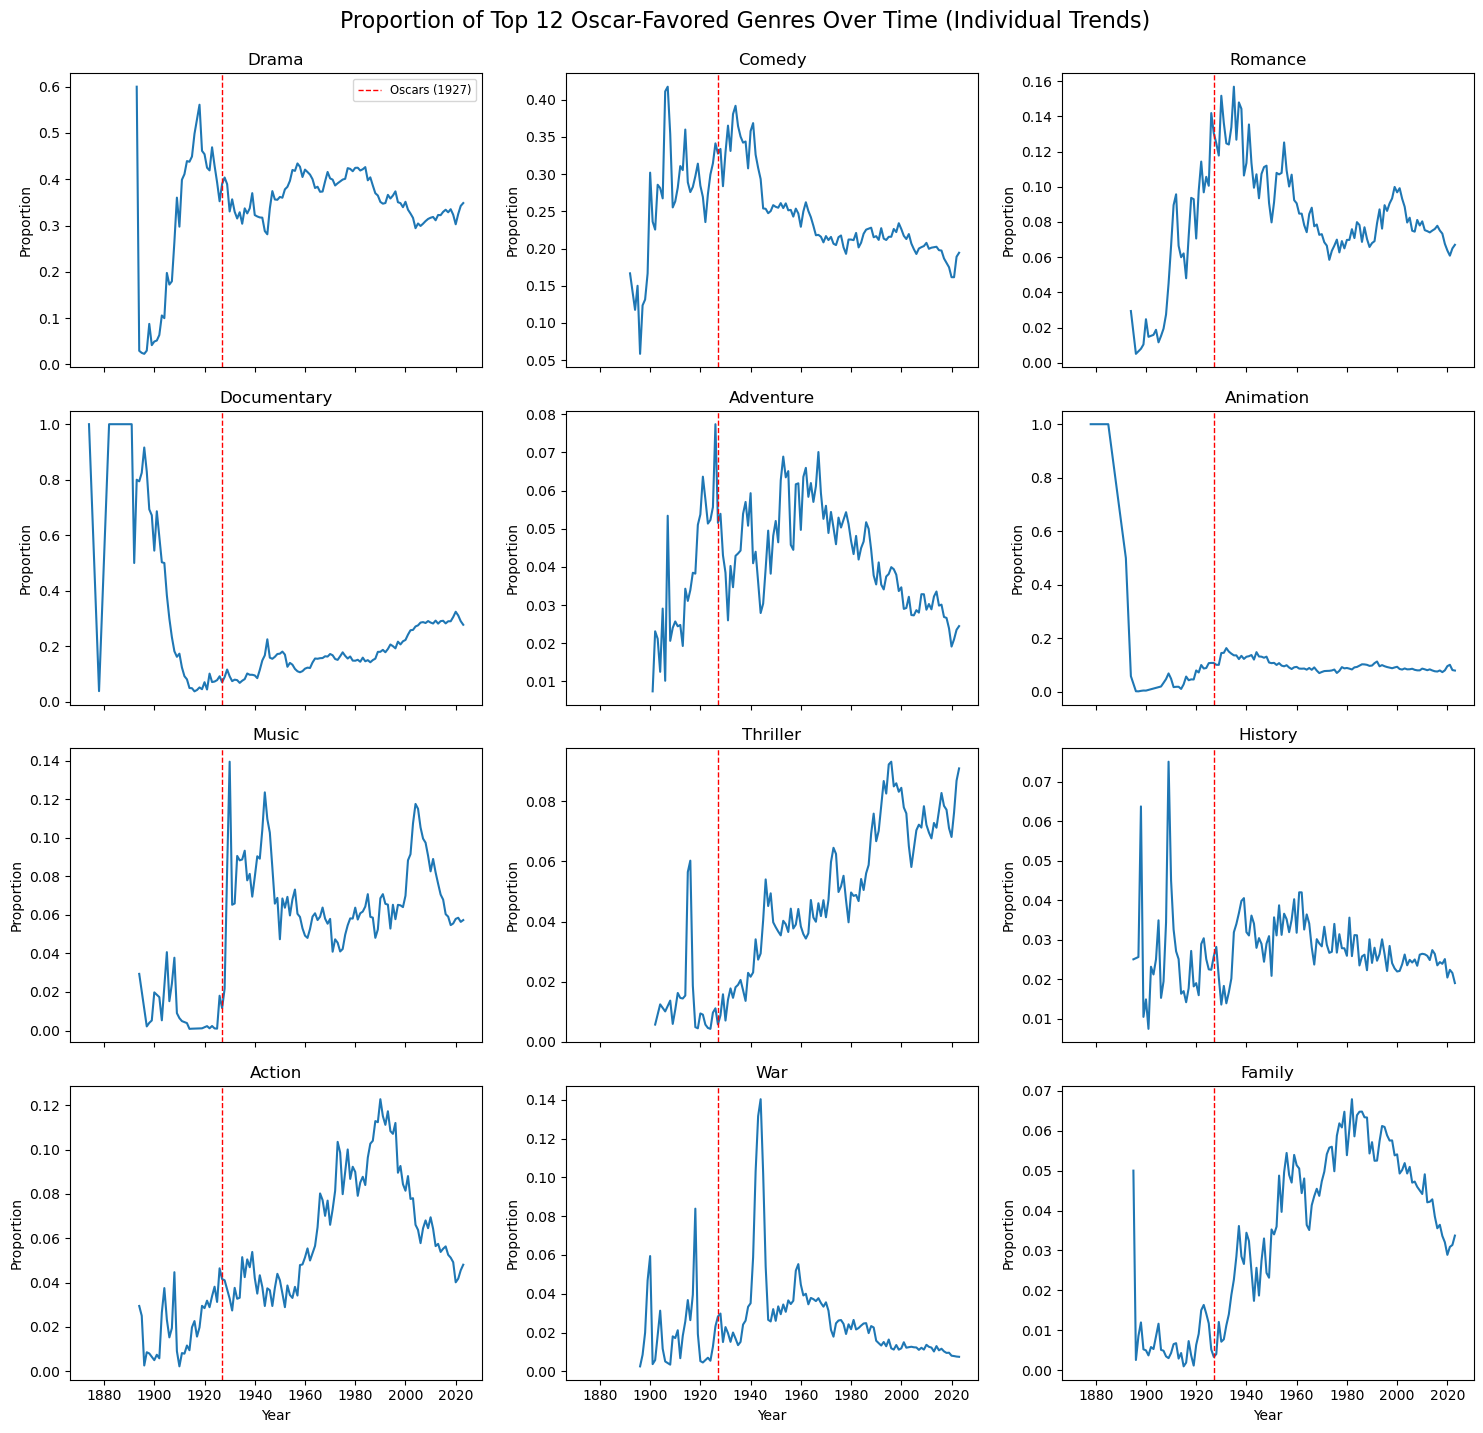

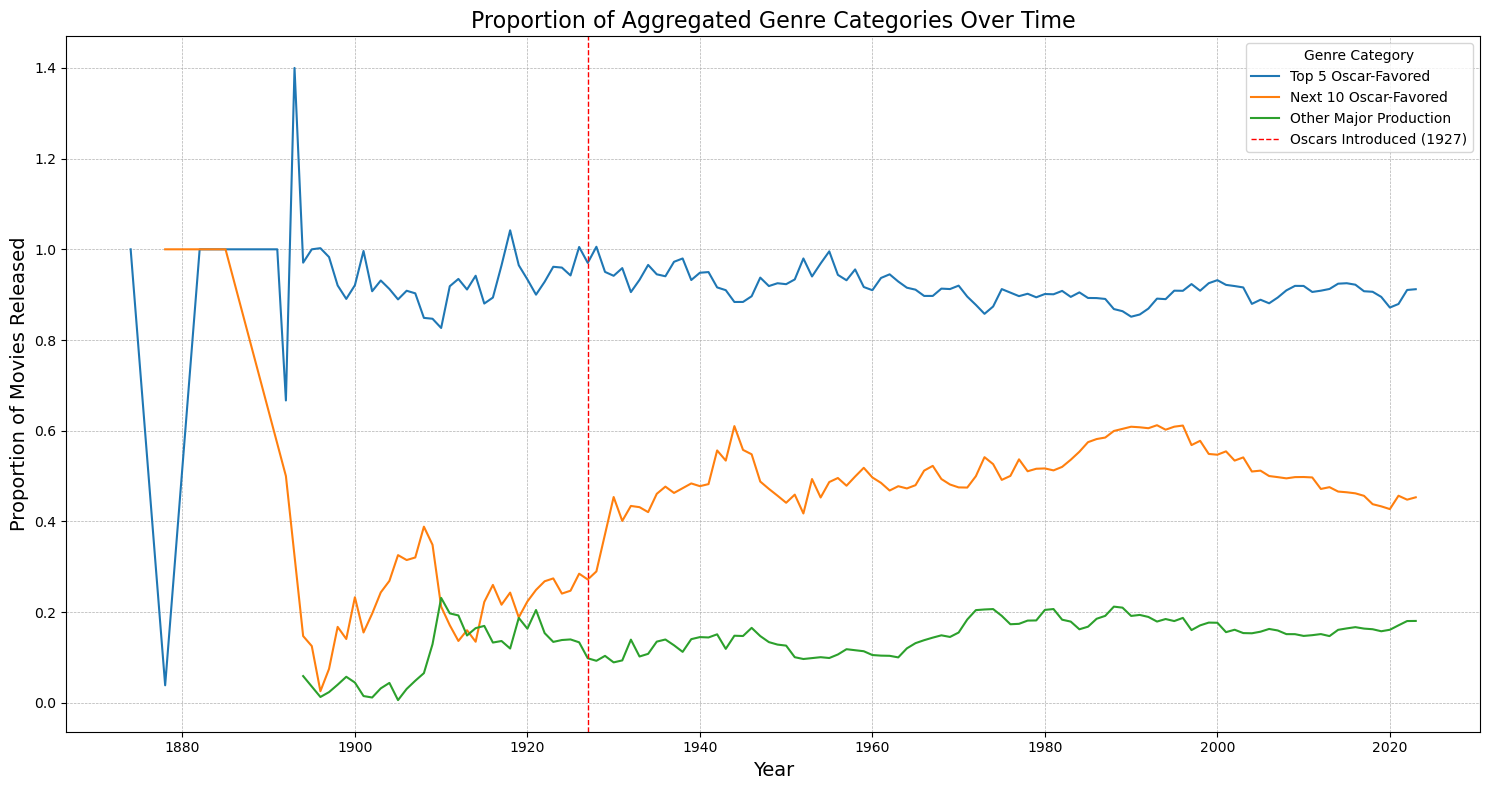

In [6]:
# Calculating Oscar-Favored Genres
nominated_movies_with_genres = core_movies_df[
    ((core_movies_df['num_oscar_nominations'] > 0) | (core_movies_df['num_oscar_wins'] > 0)) &
    (core_movies_df['genres_list'].apply(lambda x: isinstance(x, list) and len(x) > 0))
    ].copy()

all_nominated_genres = nominated_movies_with_genres.explode('genres_list')['genres_list']
nominated_genre_counts = all_nominated_genres.value_counts()
top_oscar_genres = nominated_genre_counts.head(N_TOP_GENRES).index.tolist()

# Preparing DataFrame for Genre Trend Analysis
genre_analysis_df = core_movies_df[
    core_movies_df['global_release_year'].notna() &
    (core_movies_df['genres_list'].apply(lambda x: isinstance(x, list) and len(x) > 0))
    ].copy()
genre_analysis_df['global_release_year'] = genre_analysis_df['global_release_year'].astype(int)

exploded_genres_df = genre_analysis_df.explode('genres_list').rename(columns={'genres_list': 'genre'})

genre_yearly_stats = exploded_genres_df.groupby(['global_release_year', 'genre']).agg(
    num_films_produced=('id', 'nunique'),
    num_films_with_any_nomination=('num_oscar_nominations', lambda x: (x > 0).sum()),
    num_films_with_any_win=('num_oscar_wins', lambda x: (x > 0).sum())
).reset_index()

genre_yearly_stats[['num_films_with_any_nomination', 'num_films_with_any_win']] = \
    genre_yearly_stats[['num_films_with_any_nomination', 'num_films_with_any_win']].astype(int)

movies_per_year = genre_analysis_df.groupby('global_release_year')['id'].nunique()
genre_yearly_stats = pd.merge(
    genre_yearly_stats,
    movies_per_year.rename('total_movies_in_year'),
    on='global_release_year'
)

genre_yearly_stats['proportion'] = genre_yearly_stats['num_films_produced'] / genre_yearly_stats['total_movies_in_year']

# Create Lagged Variables for Oscar Success
analysis_data_lagged = genre_yearly_stats.copy()
analysis_data_lagged['prev_year_films_nominated'] = (
    analysis_data_lagged.groupby('genre')['num_films_with_any_nomination']
    .shift(1).fillna(0).astype(int)
)
analysis_data_lagged['prev_year_films_won'] = (
    analysis_data_lagged.groupby('genre')['num_films_with_any_win']
    .shift(1).fillna(0).astype(int)
)

# Visualization for Selected Top Genres (Individual Trends)
num_genres_for_facet = 12
genres_to_plot_facet = top_oscar_genres[:num_genres_for_facet]
plot_data_facet = genre_yearly_stats[genre_yearly_stats['genre'].isin(genres_to_plot_facet)]

n_cols = 3
n_rows = int(np.ceil(len(genres_to_plot_facet) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5), sharex=True)
axes = axes.flatten()

for idx, genre in enumerate(genres_to_plot_facet):
    genre_data = plot_data_facet[plot_data_facet['genre'] == genre]
    sns.lineplot(data=genre_data, x='global_release_year', y='proportion', ax=axes[idx], errorbar=None)
    axes[idx].set_title(genre, fontsize=12)
    axes[idx].set_ylabel("Proportion", fontsize=10)
    axes[idx].set_xlabel("Year", fontsize=10)
    axes[idx].axvline(oscar_intro_year, color='red', linestyle='--', linewidth=1, label=f'Oscars ({oscar_intro_year})')
    if idx == 0:
        axes[idx].legend(fontsize='small')

# Remove unused subplots
for ax in axes[len(genres_to_plot_facet):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.suptitle(f'Proportion of Top {num_genres_for_facet} Oscar-Favored Genres Over Time (Individual Trends)',
             fontsize=16, y=1.02)
plt.show()

# Plotting Aggregated Categories
top_5_genres = top_oscar_genres[:5]
next_10_genres = top_oscar_genres[5:15]

agg_proportions_df = genre_yearly_stats.copy()
agg_proportions_df['Category'] = np.select(
    [
        agg_proportions_df['genre'].isin(top_5_genres),
        agg_proportions_df['genre'].isin(next_10_genres)
    ],
    [
        'Top 5 Oscar-Favored',
        'Next 10 Oscar-Favored'
    ],
    default='Other Major Production'
)

agg_proportions_df = (
    agg_proportions_df.groupby(['global_release_year', 'Category'])['proportion']
    .sum().reset_index()
)
agg_proportions_df = agg_proportions_df[agg_proportions_df['proportion'] > 0.0001]

plt.figure(figsize=(15, 8))
sns.lineplot(data=agg_proportions_df, x='global_release_year', y='proportion', hue='Category', legend='full')
plt.title('Proportion of Aggregated Genre Categories Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Proportion of Movies Released', fontsize=14)
plt.axvline(oscar_intro_year, color='red', linestyle='--', linewidth=1,
            label=f'Oscars Introduced ({oscar_intro_year})')
plt.legend(title='Genre Category')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

#### Interpreting Genre Trends Over Time
Several key trends emerge from this longitudinal examination:

- **Drama's Enduring Supremacy:** While Drama has consistently dominated the cinematic landscape throughout film history, its prevalence among Oscar-recognized films significantly exceeds its general production share. This pattern has remained remarkably stable over time, reinforcing Drama's position as the Academy's preferred narrative form.
- **The Recognition Gap:** Popular mainstream genres such as Comedy and Adventure, despite maintaining substantial production volumes across decades, consistently underperform in Oscar recognition relative to their market presence.
- **Elevated Genre Recognition:** Documentary and Romance demonstrate notably higher recognition rates among Oscar contenders compared to their proportional representation in overall film production. This elevation indicates the Academy's particular appreciation for both factual storytelling and intimate character-driven narratives.
- **Expanding Academy Horizons:** The most significant evolutionary trend appears in the "Next 10 Oscar-Favored" category, which has shown marked growth over time. While the "Top 5" core genres have maintained relatively stable recognition patterns, this expansion suggests the Academy has gradually broadened its appreciation for diverse storytelling approaches, indicating a slow but meaningful shift toward greater genre inclusivity in awards consideration.

### Putting it all into Prospective

This comparative analysis exposes the stark contrasts between what gets produced and what gets celebrated, revealing the Academy's selective criteria for cinematic excellence. The following visualization illuminates these disparities and helps identify which storytelling approaches consistently capture the Academy's attention versus those that struggle for recognition.

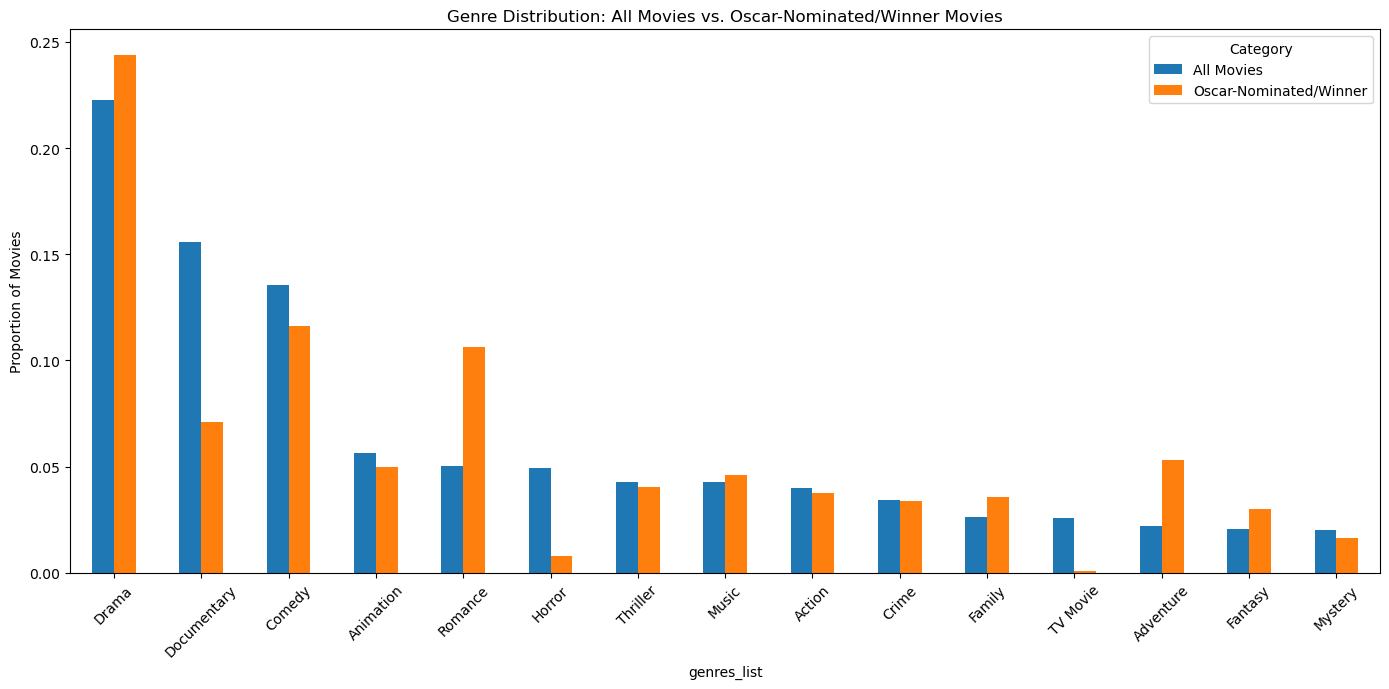

In [7]:
# Use exploded_all_genres and all_nominated_genres from previous cells
genre_counts_all = exploded_all_genres['genres_list'].value_counts(normalize=True)
genre_counts_nominated = all_nominated_genres.value_counts(normalize=True)

# Use the same top genres as before for consistency
top_genres = genre_counts_all.head(N_TOP_GENRES).index

# Combine into a DataFrame
genre_compare_df = pd.DataFrame({
    'All Movies': genre_counts_all,
    'Oscar-Nominated/Winner': genre_counts_nominated
}).fillna(0).loc[top_genres]

# Plot grouped bar chart
genre_compare_df.plot(kind='bar', figsize=(14, 7))
plt.ylabel('Proportion of Movies')
plt.title('Genre Distribution: All Movies vs. Oscar-Nominated/Winner Movies')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

#### The results:
- **Dramatic Storytelling Dominance:** Drama maintains an even stronger presence among Oscar-recognized films compared to general film production.
- **Genre Gaps in Recognition:** Popular entertainment genres like Comedy and Adventure show significant underrepresentation in Oscar categories relative to their production volume, suggesting potential barriers these genres face in achieving critical acclaim within Academy circles.
- **Documentary and Romance Elevation:** Both Documentary and Romance genres demonstrate disproportionately high recognition rates among Oscar contenders compared to their overall market share, indicating the Academy's particular appreciation for factual storytelling and intimate human relationships.
- **Commercial vs. Critical Divide:** High-production genres including Action, Thriller, and Family entertainment maintain substantial presence in general filmmaking but receive proportionally fewer Oscar acknowledgments, highlighting a potential disconnect between commercial success and awards recognition.

This genre analysis illuminates the Academy's selective approach to recognizing cinematic excellence, with clear preferences for certain narrative styles over others.

---


## The Global Stage: Production Countries and the Oscars
While the Academy Awards originated as a celebration of Hollywood cinema, they have evolved into a truly international platform that recognizes outstanding filmmaking achievements from across the globe.

The Academy has introduced **awards aimed to Foreign Cinema**, ruling that a movie to be considered as **foreign** it has to be produced **outside of the US** and to **not have english as its primary language**.

Our investigation addresses several critical questions about the international scope of the Oscars:
1. **International Oscar Champions:** Which countries outside the United States have established themselves as consistent producers of Oscar-nominated and winning films, in international and foreign-language categories?
2.  **The Academy International Menu** Does the Academy prefer particular kinds of movies in the international spectre?
3. **Cultural Storytelling Preferences:** Do international movies reflect their coutry of origin?

### 1. International Oscar Champions

In [8]:
import pycountry
import plotly.express as px

us_country_name = "United States of America"

# Step 1: Filter for films that were nominated or won in the 'Foreign International' category.
# This part is correct and directly uses the boolean columns.
strictly_foreign_films_df = core_movies_df[
    (core_movies_df['foreign_international_nominated'] | core_movies_df['foreign_international_won'])
].copy()

# Step 2: Convert 'production_countries_list' from string representation to actual Python lists.
# Handle potential NaN values by converting them to empty lists, and correctly parse string lists.
strictly_foreign_films_df['production_countries_list'] = strictly_foreign_films_df['production_countries_list'].apply(
    lambda x: x if isinstance(x, list) else []
)

# Step 3: Filter out movies where 'us_country_name' is present in their production_countries_list.
# The '~' operator negates the boolean result, so it keeps rows where US is NOT in the list.
strictly_foreign_films_df = strictly_foreign_films_df[
    ~strictly_foreign_films_df['production_countries_list'].apply(lambda countries: us_country_name in countries)
].copy()

# --- Part 2: Attribute Oscar Success to Countries for These Films ---
exploded_sf_countries_df = strictly_foreign_films_df.explode('production_countries_list')
exploded_sf_countries_df.rename(columns={'production_countries_list': 'country'}, inplace=True)

sf_country_stats_df = exploded_sf_countries_df.groupby('country').agg(
    Number_of_Nominated_Movies=('num_oscar_nominations', lambda x: (x > 0).sum()),
    Number_of_Winner_Movies=('num_oscar_wins', lambda x: (x > 0).sum())
).reset_index()

sf_country_stats_df['Number_of_Nominated_Movies'] = sf_country_stats_df['Number_of_Nominated_Movies'].astype(int)
sf_country_stats_df['Number_of_Winner_Movies'] = sf_country_stats_df['Number_of_Winner_Movies'].astype(int)

# --- Part 3: Geographical Visualization ---

_country_code_cache = {}


def get_iso_alpha3(country_name):
    if country_name in _country_code_cache:
        return _country_code_cache[country_name]
    try:
        country = pycountry.countries.search_fuzzy(country_name)
        if country:
            code = country[0].alpha_3
            _country_code_cache[country_name] = code
            return code
        else:
            # Handle common variations or specific cases manually if pycountry fails
            if country_name == "Soviet Union":
                code = "RUS"
                _country_code_cache[country_name] = code
                return code
            if country_name == "West Germany":
                code = "DEU"
                _country_code_cache[country_name] = code
                return code
            _country_code_cache[country_name] = None
            return None
    except Exception:
        _country_code_cache[country_name] = None
        return None


sf_country_stats_df['iso_alpha3'] = sf_country_stats_df['country'].apply(get_iso_alpha3)

fig_nominated = px.choropleth(sf_country_stats_df,
                              locations="iso_alpha3",
                              color="Number_of_Nominated_Movies",
                              hover_name="country",
                              color_continuous_scale=px.colors.sequential.YlOrRd,
                              title="Number of Oscar-Nominated 'Strictly Foreign' Films by Country",
                              template="plotly_dark")
fig_nominated.show()

fig_won = px.choropleth(sf_country_stats_df,
                        locations="iso_alpha3",
                        color="Number_of_Winner_Movies",
                        hover_name="country",
                        color_continuous_scale=px.colors.sequential.Greens,
                        title="Number of Oscar-Winning 'Strictly Foreign' Films by Country",
                        template="plotly_dark")
fig_won.show()

### Global Oscar Recognition Patterns
The visualizations reveal compelling patterns in how the Academy recognizes cinematic excellence across different regions and cultures.

**European Cinema Leadership:** The maps clearly demonstrate the strong presence of European filmmaking traditions at the Oscars, with France, Germany, and Italy emerging as consistent powerhouses in international recognition. France's particularly impressive performance across both nominations and wins underscores its enduring influence and reputation for artistic filmmaking excellence.

**Global Reach Beyond Europe:** While European countries dominate, the maps also showcase meaningful contributions from diverse regions including Asia, the Americas, and other continents.

**Cultural Bridge-Building:** These geographic patterns illustrate how the Academy Awards serve as a bridge between different cultural traditions and cinematic approaches. The international recognition reflects not just Hollywood's expanding global perspective, but also the universal language of compelling filmmaking.

### 2. **The Academy International Menu** 
Does the Academy prefer particular kinds of movies in the international spectre?

In [9]:
from collections import Counter
foreign_film_genres_exploded = strictly_foreign_films_df.explode('genres_list')

# Step 5: Count the occurrences of each genre
genre_counts = Counter(foreign_film_genres_exploded['genres_list'])
N_TOP_GENRES = 15
top_genres = genre_counts.most_common(N_TOP_GENRES)

# Prepare data for plotting
top_genres_foreign_movies_df = pd.DataFrame(top_genres, columns=['Genre', 'Count'])
top_genres_foreign_movies_df = top_genres_foreign_movies_df.sort_values(by='Count', ascending=False)
fig_pie = px.pie(top_genres_foreign_movies_df,
                 names='Genre',
                 values='Count',
                 title=f'Top {N_TOP_GENRES} Genres for Strictly Foreign Oscar-Nominated/Winning Films',
                 template="plotly_dark",
                 color='Genre'
                 )
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.show()

#### Genre Insights for "Strictly Foreign" Oscar Films
The pie chart shows that **Drama** overwhelmingly dominates among strictly foreign Oscar contenders, reflecting the Academy’s strong preference for dramatic storytelling. **War** and **Romance** genres are also notably prominent, suggesting that international films focusing on historical events or universal love stories resonate well with the Academy. **Comedy** is less common, likely due to cultural differences in humor. The presence of **Documentary** films highlights the Academy’s appreciation for impactful non-fiction stories. Overall, foreign Oscar-nominated films succeed most with genres that emphasize drama, history, and human relationships.


#### Let's compare these genres with the rest of Oscar acclaimed movies

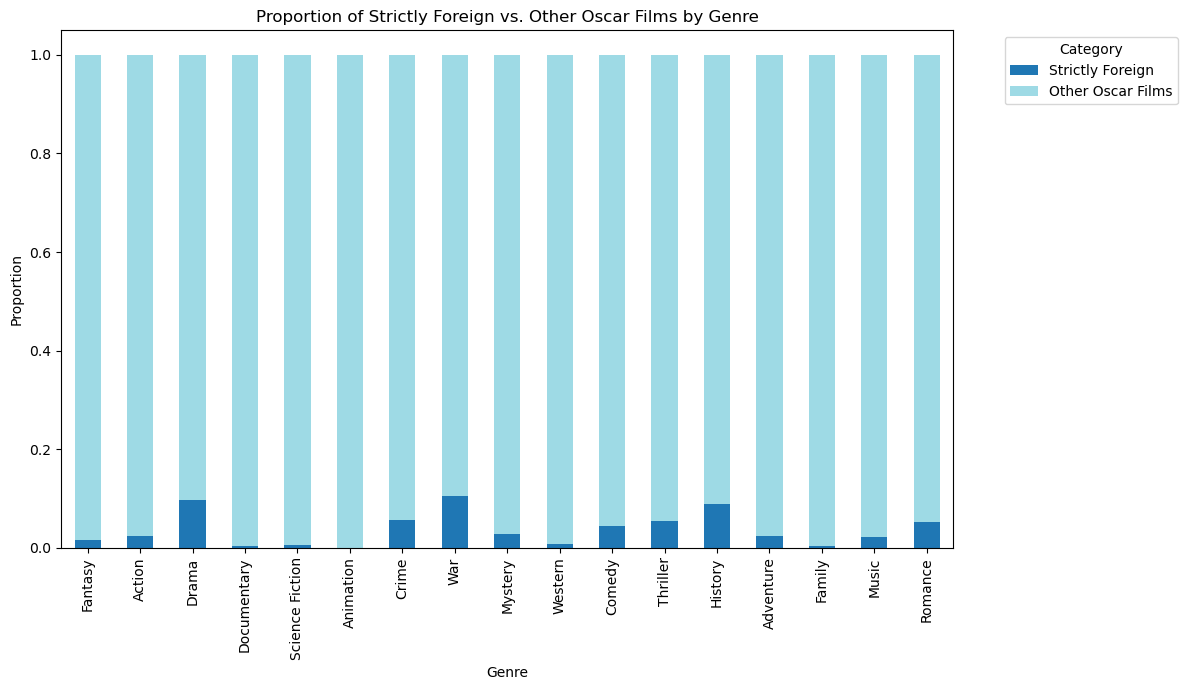

In [10]:
# Stacked bar chart: one bar per genre, showing the split between Strictly Foreign and Other Oscar Films
# Prepare other Oscar-nominated/winning films (not strictly foreign)
other_oscar = core_movies_df[
    ((core_movies_df['num_oscar_nominations'] > 0) | (core_movies_df['num_oscar_wins'] > 0))
    & ~((core_movies_df['foreign_international_nominated'] | core_movies_df['foreign_international_won'])
         & core_movies_df['production_countries_list'].apply(lambda x: isinstance(x, list) and "United States of America" not in x))
    & core_movies_df['genres_list'].apply(lambda x: isinstance(x, list) and len(x) > 0)
].copy()
other_oscar_genres = other_oscar.explode('genres_list')['genres_list']
# Reuse previous counts
foreign_counts = foreign_film_genres_exploded['genres_list'].value_counts()
other_counts = other_oscar_genres.value_counts()

top_genres = list(set(foreign_counts.head(N_TOP_GENRES).index).union(other_counts.head(N_TOP_GENRES).index))

# Prepare DataFrame for stacking by genre (each genre is a bar, split by group)
genres_comparison_df = pd.DataFrame({
    'Strictly Foreign': foreign_counts,
    'Other Oscar Films': other_counts
}).fillna(0).loc[top_genres]

# Normalize to proportions per genre (so each bar sums to 1)
df_prop = genres_comparison_df.div(genres_comparison_df.sum(axis=1), axis=0)

# Plot: stacked bar for each genre
ax = df_prop.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.ylabel('Proportion')
plt.xlabel('Genre')
plt.title('Proportion of Strictly Foreign vs. Other Oscar Films by Genre')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Interpreting the Comparison
The stacked bar shows how the Academy strong preference for genres such as **War**, **History**, and Drama when it comes to international movies. This trend likely reflects the significant impact of major historical events—particularly the First and Second World Wars—on international cinema and the types of stories that resonate with Academy voters.

### 3. **Cultural Storytelling Preferences:** 
Do international Academy acclaimed movies reflect their coutry of origin?

In [11]:
import pycountry_convert as pc

target_genres = ["War", "History"]

# Filter for strictly foreign films with War or History genres, safely handling None values
sf_war_history = strictly_foreign_films_df[
    strictly_foreign_films_df['genres_list'].apply(
        lambda genres: isinstance(genres, list) and any(g in target_genres for g in genres)
    )
].copy()

sf_war_history_exploded = sf_war_history.explode('production_countries_list')

# Helper to get continent from country name
def country_to_continent(country):
    try:
        country_code = pc.country_name_to_country_alpha2(country, cn_name_format="default")
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except Exception:
        return "Other/Unknown"

# Prepare DataFrame for sunburst/treemap
sf_war_history_exploded['Continent'] = sf_war_history_exploded['production_countries_list'].apply(country_to_continent)
plot_df = sf_war_history_exploded.groupby(['Continent', 'production_countries_list']).size().reset_index(name='Count')

# Sunburst plot: Continent > Country
fig = px.sunburst(
    plot_df,
    path=['Continent', 'production_countries_list'],
    values='Count',
    title="Continent and Country Distribution of Strictly Foreign Oscar-Nominated/Winning War/History Films",
    template="plotly_dark"
)
fig.show()

### Geographic Patterns in Oscar-Recognized War and History Films

The sunburst chart above reveals how strictly foreign Oscar-nominated and winning films in the War and History genres are distributed across continents and countries. European **nations**, particularly those **with significant historical involvement in major conflicts**, are **especially prominent**. This geographic concentration highlights the strong influence of European history and culture on internationally recognized cinema in these genres. The visualization also demonstrates the global reach of impactful storytelling, with contributions from countries across multiple continents, reflecting the universal resonance of war and historical narratives in the eyes of the Academy.

### **Tackling down to the numbers**

In [12]:
# Funnel data: all strictly foreign, then those with War/History, then nominated, then winners
total_strictly_foreign = len(strictly_foreign_films_df)
sf_war_history = strictly_foreign_films_df[
    strictly_foreign_films_df['genres_list'].apply(
        lambda genres: isinstance(genres, list) and any(g in ["War", "History"] for g in genres)
    )
]
nominated = (sf_war_history['num_oscar_nominations'] > 0).sum()
winners = (sf_war_history['num_oscar_wins'] > 0).sum()

funnel_data = {
    "Stage": [
        "All Strictly Foreign Films",
        "Oscar-Nominated (War/History)",
        "Oscar-Winning (War/History)"
    ],
    "Count": [
        total_strictly_foreign,
        nominated,
        winners
    ]
}

fig = px.funnel(funnel_data, x="Count", y="Stage", title="Funnel of Strictly Foreign War/History Films to Oscar Recognition")
fig.show()

### From Global Production to Oscar Recognition: War and History Films

To quantify the journey of War and History films from international production to Oscar acclaim, we visualize a funnel that tracks the number of strictly foreign films, those about War or History that have been nominated and how many of the latter received an award. It underscores how only a small fraction of globally produced War and History films achieve the highest level of critical acclaim on the Oscar stage.

## Conclusion: Unpacking the Oscar Code

This comprehensive analysis of movie data has illuminated several key patterns and enduring preferences of the Academy Awards, revealing a complex interplay of strategic industry practices, evolving genre, and specific international cinematic recognition.

**Strategic Timing and the "Oscar Season":**
Our exploration of release dates confirmed the existence of an "Oscar season." While overall movie releases show broad seasonal trends, a distinct pattern emerges for Oscar-nominated and winning films, which are disproportionately released towards the end of the calendar year, suggesting a strategic alignment by studios to maximize visibility and consideration during the crucial awards voting period.

**Genre Preferences: Drama's Reign and Evolving Tastes:**
Genre analysis consistently highlighted **Drama** as the Academy's favored storytelling mode, both in general and among international selections. This preference has remained remarkably stable throughout Oscar history. Conversely, high-production, popular genres like Comedy and Adventure often see a "recognition gap," being less represented in nominations and wins relative to their overall production volume. However, genres like Documentary and Romance receive disproportionately high recognition, indicating the Academy's appreciation for factual storytelling and intimate narratives.

**The Global Stage: A European Focus with Specific Tastes:**
When examining international films, European cinema—particularly from **France, Italy, and Germany** emerges as the dominant force, consistently producing Oscar-nominated and winning films. The Academy's *"international menu"* for these *"strictly foreign"* films also shows a strong preference for **Drama, War, and History**. This focus, especially on War and History, likely reflects the profound impact of major global conflicts (such as the World Wars) on international cinema and the types of narratives that resonate with Academy voters.

**The Narrow Path to Gold:**
The funnel analysis, particularly for strictly foreign War/History films, starkly illustrated the highly selective nature of Oscar recognition. From the vast pool of international productions, only a small fraction receive nominations, and an even smaller subset achieve a win. This underscores that while the Oscars provide a global platform, achieving recognition remains an exceptionally competitive endeavor, especially for films navigating specific categories and genre expectations.

**Final Thoughts:**
In essence, the Academy Awards, while evolving, operate with a discernible set of preferences. Dramatic depth, historical significance (especially in international contexts), and strategic release timing appear to be key ingredients in the recipe for Oscar consideration. While Hollywood remains central, the Oscars have undeniably become a global institution, yet one that still views international cinema through a particular lens, often favoring narratives that align with established Western historical and dramatic sensibilities. The journey to an Oscar is a testament to not only cinematic excellence but also to navigating these complex, often unwritten, rules of the Academy.